DNA SEQUENCE ANALYSIS & MUTATION DETECTION

[1] DNA SEQUENCE STATISTICS

TP53_Normal:
  Length: 176 bp
  A: 47 (26.7%)
  T: 40 (22.7%)
  G: 56 (31.8%)
  C: 33 (18.8%)
  GC Content: 50.6%

TP53_Mutation_1:
  Length: 176 bp
  A: 47 (26.7%)
  T: 40 (22.7%)
  G: 56 (31.8%)
  C: 33 (18.8%)
  GC Content: 50.6%

BRCA1_Normal:
  Length: 166 bp
  A: 40 (24.1%)
  T: 34 (20.5%)
  G: 48 (28.9%)
  C: 44 (26.5%)
  GC Content: 55.4%


[2] MUTATION DETECTION & COMPARISON

Comparing TP53_Mutation_1 to TP53_Normal:
  Total SNPs found: 0

Comparing BRCA1_Normal to TP53_Normal:
  Total SNPs found: 129
    Position 5: G → T
    Position 6: A → T
    Position 8: C → A
    Position 9: C → A
    Position 10: G → C
    Position 11: G → T
    Position 12: G → T
    Position 13: G → T
    Position 15: A → C
    Position 16: G → C
    Position 17: T → C
    Position 20: C → A
    Position 22: C → T
    Position 24: C → T
    Position 25: T → G
    Position 26: T → A
    Position 28: C → A
    Position 29: C → T
 

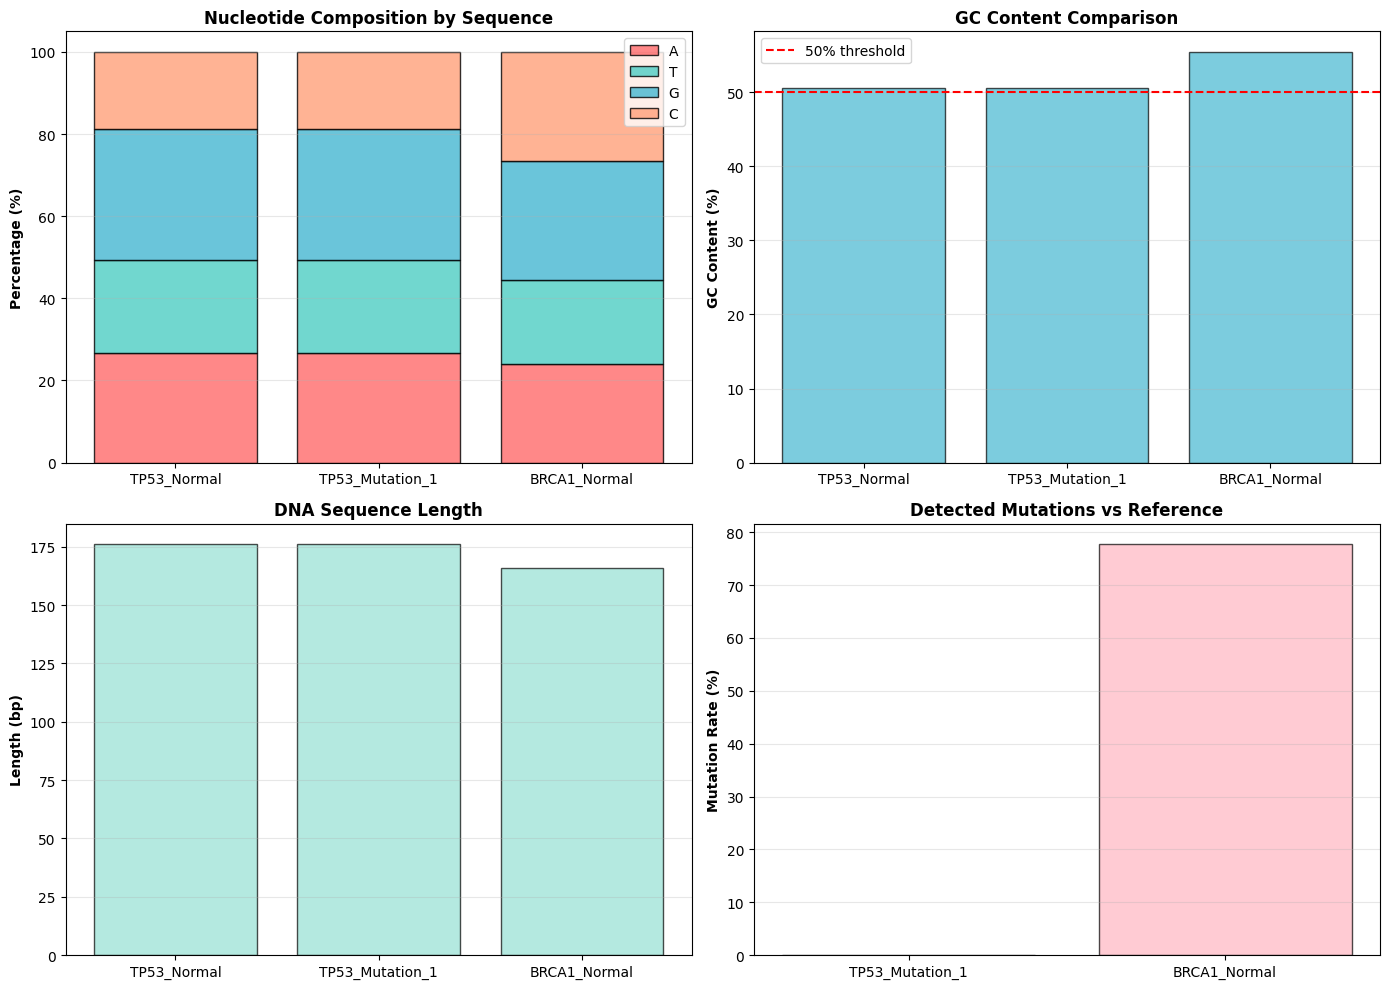


ANALYSIS COMPLETE

Biological Significance:
- GC content affects DNA stability and primer design
- SNPs can alter protein function and disease susceptibility
- Mutation detection is crucial for cancer diagnostics

Applications:
- Cancer mutation screening
- Population genetics
- Molecular diagnostics


In [1]:
# DNA Sequence Analysis & Mutation Detection Pipeline
# Analyze DNA sequences, identify mutations, calculate GC content

from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("DNA SEQUENCE ANALYSIS & MUTATION DETECTION")
print("=" * 70)

# Sample cancer-related DNA sequences
sequences = {
    'TP53_Normal': 'ATGAGAGCCGGGGCAGTGTCTCACTTACCGTCACTCGACAGAGACAGAATGAGACTTGAGATCT'
                   'GATGAGTTGGGAGAGAGGTGATCCATGAGTAGAGAGCGTCTGCAAACTTTGAGGAGTGCAAAGATTT'
                   'GGTGAGCTAGGTGACTGCCCCGTGTCTAGACTAGCTAGCTAGCTA',

    'TP53_Mutation_1': 'ATGAGAGCCGGGGCAGTGTCTCACTTACCGTCACTCGACAGAGACAGAATGAGACTTGAGATCT'
                       'GATGAGTTGGGAGAGAGGTGATCCATGAGTAGAGAGCGTCTGCAAACTTTGAGGAGTGCAAAGA'
                       'TTTGGTGAGCTAGGTGACTGCCCCGTGTCTAGACTAGCTAGCTAGCT_A',  # SNP

    'BRCA1_Normal': 'ATGATTGAACTTTCCCCGTATTATGAAATAATGATTTTCTACAAACTCTGGTACGTGTCAGCGTGA'
                    'TCGCGATCCGCCCCGACGCCGCCGCCTCTTTGCGCAGAGCCGGGGGATAGACCGAGCGTGTGGAGGA'
                    'GTGAACGACGACGATGACGACGACGACGACGAC',
}

# ============================================================================
# ANALYSIS 1: SEQUENCE STATISTICS
# ============================================================================

print("\n[1] DNA SEQUENCE STATISTICS\n")

stats_results = []

for seq_name, sequence in sequences.items():
    # Clean sequence
    sequence = sequence.replace('_', '').upper()

    # Count nucleotides
    nucleotide_count = Counter(sequence)

    # Calculate percentages
    gc_content = ((nucleotide_count['G'] + nucleotide_count['C']) / len(sequence)) * 100
    at_content = ((nucleotide_count['A'] + nucleotide_count['T']) / len(sequence)) * 100

    stats_results.append({
        'Sequence': seq_name,
        'Length_bp': len(sequence),
        'A_%': round((nucleotide_count['A']/len(sequence))*100, 2),
        'T_%': round((nucleotide_count['T']/len(sequence))*100, 2),
        'G_%': round((nucleotide_count['G']/len(sequence))*100, 2),
        'C_%': round((nucleotide_count['C']/len(sequence))*100, 2),
        'GC_Content_%': round(gc_content, 2),
        'AT_Content_%': round(at_content, 2),
    })

    print(f"{seq_name}:")
    print(f"  Length: {len(sequence)} bp")
    print(f"  A: {nucleotide_count['A']} ({(nucleotide_count['A']/len(sequence))*100:.1f}%)")
    print(f"  T: {nucleotide_count['T']} ({(nucleotide_count['T']/len(sequence))*100:.1f}%)")
    print(f"  G: {nucleotide_count['G']} ({(nucleotide_count['G']/len(sequence))*100:.1f}%)")
    print(f"  C: {nucleotide_count['C']} ({(nucleotide_count['C']/len(sequence))*100:.1f}%)")
    print(f"  GC Content: {gc_content:.1f}%")
    print()

df_stats = pd.DataFrame(stats_results)

# ============================================================================
# ANALYSIS 2: MUTATION DETECTION
# ============================================================================

print("\n[2] MUTATION DETECTION & COMPARISON\n")

reference_seq = sequences['TP53_Normal'].replace('_', '').upper()
test_sequences = {k: v.replace('_', '').upper() for k, v in sequences.items() if k != 'TP53_Normal'}

mutations_found = []

for test_name, test_seq in test_sequences.items():
    # Find mutations
    print(f"Comparing {test_name} to TP53_Normal:")

    min_len = min(len(reference_seq), len(test_seq))

    snps = []  # Single Nucleotide Polymorphisms
    for i in range(min_len):
        if reference_seq[i] != test_seq[i]:
            snps.append({
                'Position': i+1,
                'Reference': reference_seq[i],
                'Alternate': test_seq[i],
                'Type': 'SNP'
            })

    print(f"  Total SNPs found: {len(snps)}")
    for snp in snps:
        print(f"    Position {snp['Position']}: {snp['Reference']} → {snp['Alternate']}")

    mutations_found.append({
        'Comparison': test_name,
        'SNPs': len(snps),
        'Mutation_Rate_%': round((len(snps)/min_len)*100, 2)
    })
    print()

df_mutations = pd.DataFrame(mutations_found)

# ============================================================================
# VISUALIZATION 1: NUCLEOTIDE COMPOSITION
# ============================================================================

print("\n[3] CREATING VISUALIZATIONS...\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Nucleotide composition stacked bar
ax1 = axes[0, 0]
nucleotides = ['A_%', 'T_%', 'G_%', 'C_%']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bottom = np.zeros(len(df_stats))

for nuc, color in zip(nucleotides, colors):
    ax1.bar(df_stats['Sequence'], df_stats[nuc], bottom=bottom, label=nuc[0],
            color=color, edgecolor='black', alpha=0.8)
    bottom += df_stats[nuc].values

ax1.set_ylabel('Percentage (%)', fontweight='bold')
ax1.set_title('Nucleotide Composition by Sequence', fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: GC Content
ax2 = axes[0, 1]
ax2.bar(df_stats['Sequence'], df_stats['GC_Content_%'],
        color='#45B7D1', edgecolor='black', alpha=0.7)
ax2.axhline(y=50, color='red', linestyle='--', label='50% threshold')
ax2.set_ylabel('GC Content (%)', fontweight='bold')
ax2.set_title('GC Content Comparison', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Sequence Length
ax3 = axes[1, 0]
ax3.bar(df_stats['Sequence'], df_stats['Length_bp'],
        color='#95E1D3', edgecolor='black', alpha=0.7)
ax3.set_ylabel('Length (bp)', fontweight='bold')
ax3.set_title('DNA Sequence Length', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Mutation Rate
if len(df_mutations) > 0:
    ax4 = axes[1, 1]
    ax4.bar(df_mutations['Comparison'], df_mutations['Mutation_Rate_%'],
            color='#FFB6C1', edgecolor='black', alpha=0.7)
    ax4.set_ylabel('Mutation Rate (%)', fontweight='bold')
    ax4.set_title('Detected Mutations vs Reference', fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('dna_sequence_analysis.png', dpi=300, bbox_inches='tight')
print("✓ DNA sequence analysis visualization saved")
plt.show()

# ============================================================================
# EXPORT RESULTS
# ============================================================================

df_stats.to_csv('dna_sequence_statistics.csv', index=False)
if len(df_mutations) > 0:
    df_mutations.to_csv('mutation_detection_results.csv', index=False)

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)
print("\nBiological Significance:")
print("- GC content affects DNA stability and primer design")
print("- SNPs can alter protein function and disease susceptibility")
print("- Mutation detection is crucial for cancer diagnostics")
print("\nApplications:")
print("- Cancer mutation screening")
print("- Population genetics")
print("- Molecular diagnostics")
print("=" * 70)